# Conos walkthrough: jointly analysing a panel of samples

**Conos** (*Clustering On Network of Samples*) analyses a **collection**
of single-cell samples *together*. Rather than merging all cells into
one matrix, it aligns each pair of samples in a shared space, stitches
their neighbourhoods into a single weighted graph, and then runs
clustering, embedding, and differential expression on that joint graph.
Cells of the same type connect across samples, while each sample keeps
its own structure — so you can ask:

- which cell populations are **shared** across samples?
- how do their **proportions** differ between conditions?
- can I **carry annotations** from one labelled sample to the rest?

This walkthrough runs the standard workflow end to end on a small panel
of bone-marrow (BM) and cord-blood (CB) samples. Once you are
comfortable here, the [advanced tutorial](conos-advanced.ipynb) covers
the knobs that matter when integration is harder (alignment spaces,
memory, multimodal data, label-transfer engines).

## Contents

- [Loading your data](#loading-your-data)
- [Pre-processing each sample](#pre-processing-each-sample)
- [Building the joint graph](#building-the-joint-graph)
- [Joint clustering](#joint-clustering)
- [The joint embedding](#the-joint-embedding)
- [Are the samples well mixed?](#are-the-samples-well-mixed)
- [Cluster composition across
  samples](#cluster-composition-across-samples)
- [A per-sample view](#a-per-sample-view)
- [Marker genes](#marker-genes)
- [Transferring annotations](#transferring-annotations)
- [Recap](#recap)

## Loading your data

A Conos panel is a **named list of per-sample objects** — one per
sample, each already processed with
[pagoda2](https://github.com/kharchenkolab/pagoda2) (or Seurat). You
build one object per sample from its own count data. `Pagoda2$from()`
accepts the formats you are most likely to have:

In [ ]:
library(pagoda2)

# a 10x CellRanger output folder (matrix.mtx / barcodes / features):
s1 <- Pagoda2$from10x("sample1/outs/filtered_feature_bc_matrix")

# a 10x HDF5 file:
s2 <- Pagoda2$from10xH5("sample2_filtered_feature_bc_matrix.h5")

# a counts matrix (genes x cells) you already have in memory:
s3 <- Pagoda2$from(my_counts_matrix)

One rule: **cell names must be unique across the whole panel**, so that
no two cells (even in different samples) collide. The easiest way is to
prefix each sample’s barcodes with the sample name.

For a runnable example we use a ready-made panel of four samples from
the `conosPanel` package. Each element is a sparse counts matrix (genes
× cells):

In [ ]:
library(conos)
library(pagoda2)

panel <- conosPanel::panel
str(panel, 1)

List of 4
 $ MantonBM1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonBM2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots

To keep the tutorial fast we down-sample each matrix to a few hundred
cells; in a real analysis you would use them all.

In [ ]:
set.seed(1)
panel <- lapply(panel, function(m) m[, sample(ncol(m), 600)])

## Pre-processing each sample

Each count matrix becomes a `Pagoda2` object carrying the **PCA
reduction** that Conos aligns on. A single call does it: `run()`
normalises the variance and computes the PCA
(`steps = c("variance", "pca")`), taking care of the QC and
gene-filtering prerequisites along the way. We map it over the panel:

In [ ]:
samples <- lapply(panel, function(counts) {
  Pagoda2$from(counts, verbose = FALSE)$run(steps = c("variance", "pca"), verbose = FALSE)
})

That’s the whole per-sample preparation — no manual gene-name cleanup or
parameter tuning required; the defaults are sensible for typical 10x
data.

## Building the joint graph

Create the Conos object from the per-sample objects, then build the
joint alignment graph. `runGraph()` aligns **every pair** of samples in
a shared space (`space = "PCA"`, *reciprocal PCA* — the recommended
default) and stitches their neighbourhoods into one graph. `k` sets the
inter-sample neighbourhood size and `k.self` the within-sample one.

In [ ]:
con <- Conos$new(samples, n.cores = 1)

In [ ]:
con$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)

## Joint clustering

Detect cell clusters as **communities** on the joint graph (Leiden by
default). Because the graph spans all samples, a cluster is a population
defined consistently across the whole panel:

In [ ]:
con$runClustering(verbose = FALSE)

## The joint embedding

Compute a 2-D embedding of the joint graph (UMAP) so we can look at it,
and colour it by the clusters we just found:

In [ ]:
con$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

Warning in uwot(X = X, n_neighbors = n_neighbors, n_components = n_components,
: n_components > number of columns in input data: 2 > 1, this may give poor or
unexpected results

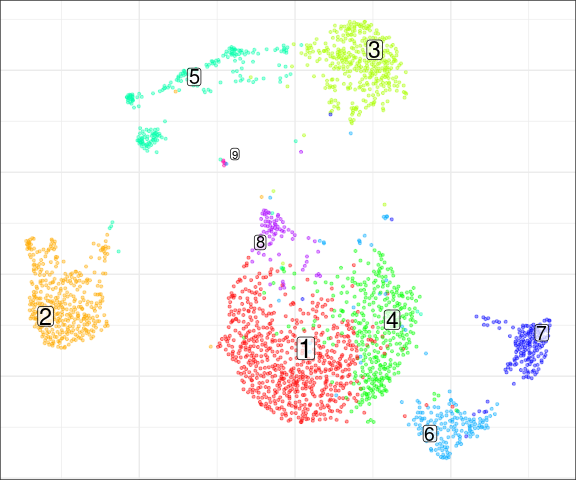

In [ ]:
con$plotGraph(clustering = "leiden")

Each blob is a cluster; nearby blobs are transcriptionally similar
populations.

## Are the samples well mixed?

This is *the* question for any integration: do the samples **overlap**
in the joint embedding (good — the same cell types are aligned across
samples), or do they sit apart (a sign of under-correction, or of
genuinely distinct populations)? Colour the *same* embedding by
**sample** instead of by cluster:

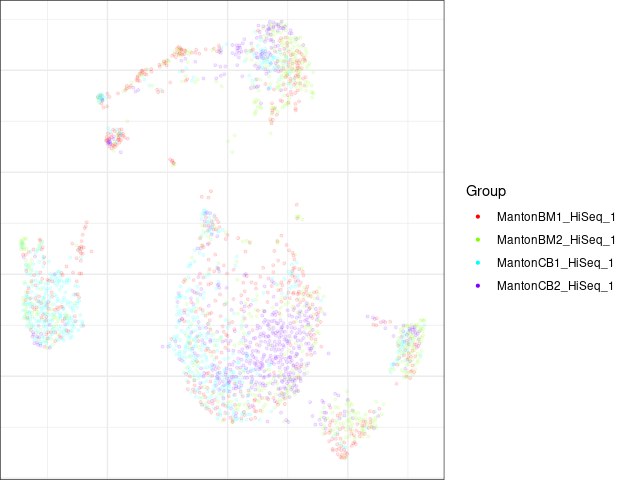

In [ ]:
con$plotGraph(color.by = "sample", mark.groups = FALSE, show.legend = TRUE, alpha = 0.1)

Cells from all four samples are interspersed within each region rather
than forming sample-specific islands, so the populations are well
aligned.

## Cluster composition across samples

`plotClusterBarplots()` shows what fraction of each cluster comes from
each sample — handy for spotting populations that are sample- or
condition-specific (here, differences between bone marrow and cord
blood):

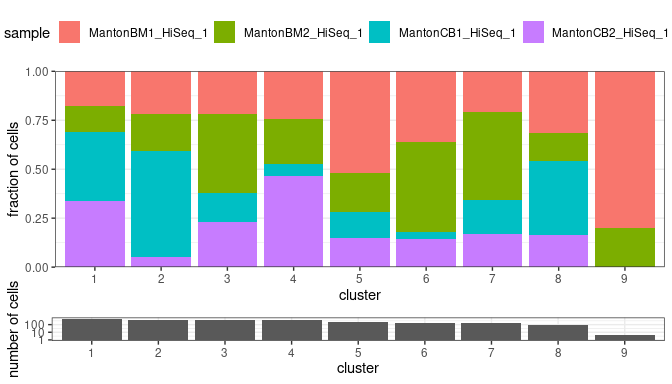

In [ ]:
plotClusterBarplots(con, clustering = "leiden", show.entropy = FALSE)

A bar split evenly across samples is a shared population; a bar
dominated by one or two samples flags a condition-specific one.

## A per-sample view

The same joint clustering laid over each sample separately. Because the
clustering is *joint*, seeing the same colours in every panel confirms
the populations are shared rather than sample-specific:

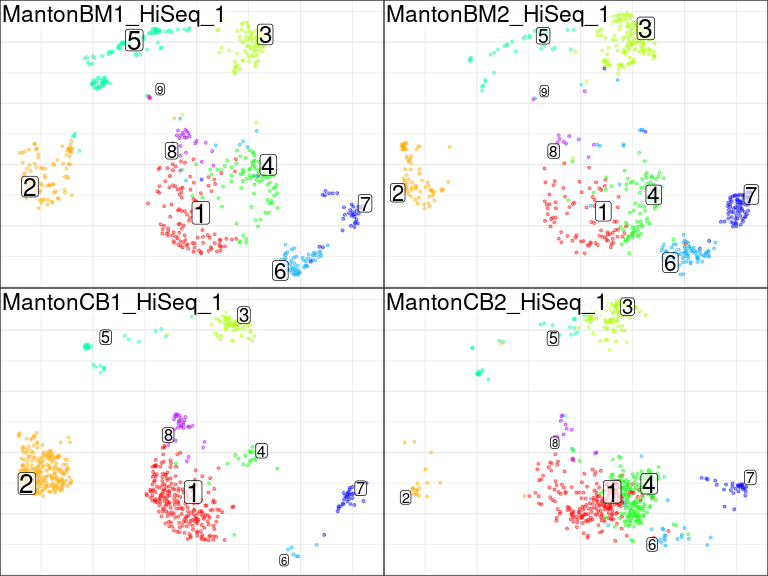

In [ ]:
con$plotPanel(clustering = "leiden", use.common.embedding = TRUE)

## Marker genes

`runMarkers()` finds genes differentially expressed between clusters,
and `plotMarkerDotPlot()` shows the top few **specific** markers per
cluster — dot **size** is the fraction of cells expressing the gene, dot
**colour** is the scaled mean expression:

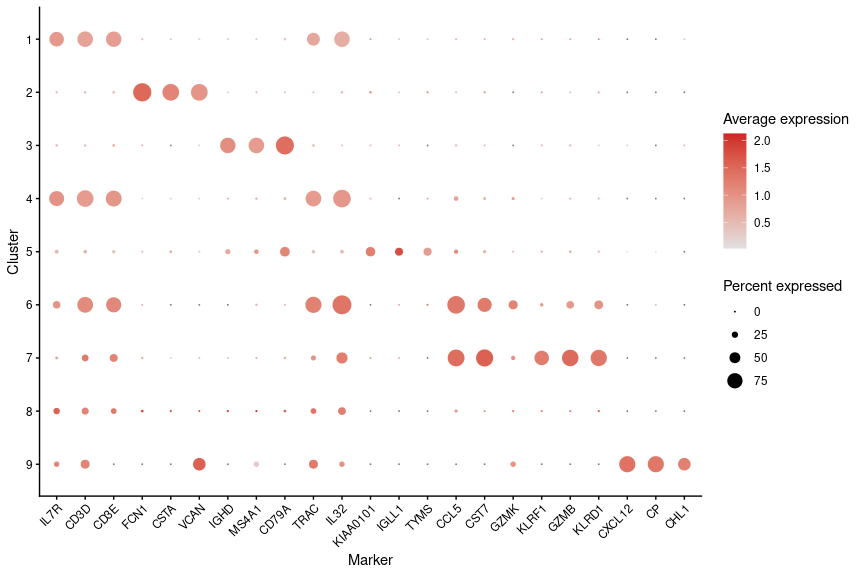

In [ ]:
con$plotMarkerDotPlot(n.genes.per.group = 3)

The diagonal pattern (each cluster lit up by its own genes) is what you
want to see — for example the T-cell (*CD3D/CD3E*), B-cell
(*MS4A1/CD79A*) and monocyte (*FCN1*) blocks.

You can also paint a single gene onto the joint embedding to see where
it is expressed:

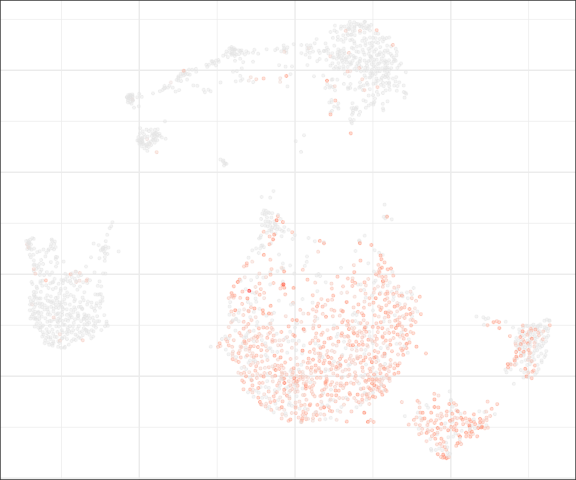

In [ ]:
con$plotGraph(gene = "CD3E")

## Transferring annotations

A common task is to carry cell-type labels from an annotated sample (or
any labelled subset) onto the rest of the panel. `propagateLabels()`
spreads labels over the joint graph and returns, per cell, a transferred
label **and** an uncertainty score.

We simulate it here: label a random 40% of cells (the “reference”) and
propagate to the other 60%.

In [ ]:
groups    <- con$clusters$leiden$groups
set.seed(1)
reference <- groups[sample(length(groups), round(0.40 * length(groups)))]

In [ ]:
transfer <- con$propagateLabels(labels = reference, verbose = FALSE)

`transfer$labels` is the propagated label for every cell. Plotted on the
embedding it recovers the original cluster structure from a sparse set
of seeds:

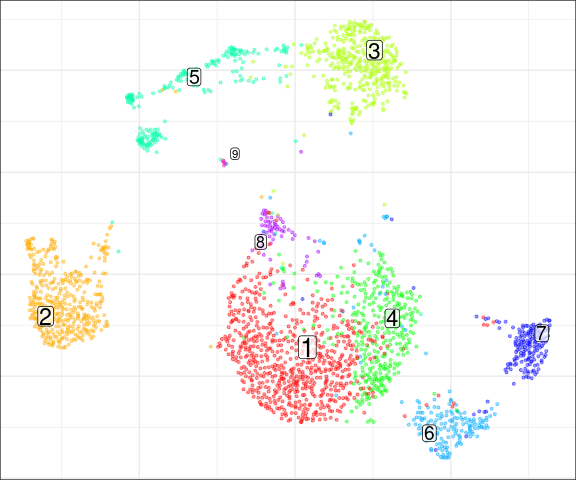

In [ ]:
con$plotGraph(groups = transfer$labels)

`transfer$uncertainty` is a 0–1 score per cell (low = confident).
Painting it onto the embedding shows *where* the transfer is trustworthy
— uncertainty rises at the boundaries between populations:

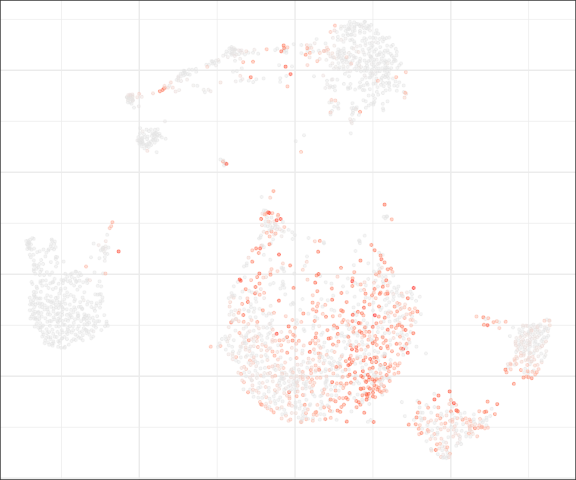

In [ ]:
con$plotGraph(colors = transfer$uncertainty)

You can threshold this score to flag cells whose transferred label is
ambiguous.

## Recap

The whole standard workflow is four calls on the Conos object:

``` r
con <- Conos$new(samples)
con$runGraph()        # align samples -> joint graph
con$runClustering()   # Leiden communities
con$runEmbedding()    # joint 2-D embedding
```

plus `plotGraph()` / `plotPanel()` / `plotClusterBarplots()` to
visualise, `runMarkers()` + `plotMarkerDotPlot()` for markers, and
`propagateLabels()` for annotation transfer. To control the alignment
space, memory use, and multimodal data, continue to the [advanced
tutorial](conos-advanced.ipynb).